
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
%%capture --no-stderr
%pip install langchain langgraph langchain-ollama tavily-python

In [3]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [2]:
import os
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain_openai import ChatOpenAI
from langchain_ollama.chat_models import ChatOllama

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a writing assistant tasked with creating well-crafted, coherent, and engaging articles based on the user's request."
            " Focus on clarity, structure, and quality to produce the best possible piece of writing."
            " If the user provides feedback or suggestions, revise and improve the writing to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# llm = ChatOpenAI(model="gpt-4o-mini")

/home/sherry/miniconda3/envs/langchain/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [4]:
writer = writer_prompt | ChatOllama(
    model="llama3.1:8b",
    max_tokens=8192,
    temperature=1.2,
)

In [5]:
article = ""

topic = HumanMessage(
    content="参考水浒传的风格，改写吴承恩的西游记中任意篇章"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

为方便起见，我选择了西游记第八回：唐僧率群僧行至清明山。这个篇章描绘的是唐僧一行与孫悟空、猪八戒、沙和尚的第一次大战。

**西游记第八回：唐僧率群僧行至清明山**

  魏国王自东来，欲征幽州盗，途次闻说唐僧正与孙悟空、猪八戒、沙和尚到蓬莱仙境学道之术，皆是神农之后，不惮远涉。魏王思之无限，下一书疏，与僧家传语欲约其来相见。唐僧得信，亦深感慕魏王之志诚，正欲回国传道也。自此知魏王果在人间求圣教，将出西域而来。

  当日僧一行自蓬莱仙境下来，过清明山关，见那高山低下，青松翠柏，清泉潆潇。一路风光都在眼前呈现。有马车之象，却没半点尘土。大抵魏王之神农后裔，不必顷刻到来。

  不远处，有一群僧，一见唐三藏便认了出来，齐声礼呼：“大师驾来！”正要行礼却被唐僧拦住。开口说的是道：“魏王诚意求学，这次我们去，他不在人间，且莫寻找。”一边说着，前面已然抵达了蓬莱仙境门口，天上阴云密布，有山高树大，以至有雨来倾。

  魏国王正待唐僧一行入关之时，也下诏书给魏帝，约定与唐僧会面。可他哪能料到唐僧的想法？既要前往，必须让三藏先到达，才好向魏王致敬。

  正当大师来到清明山上，那边魏国王下诏书来邀请三藏，约定前天会面。

这个改写以水浒传的风格为蓝本，以更加通俗直接的口吻为每一句加以润色和修饰，尽量使语言生动活泼。同时在保持了原有的典故幽默与神幻元素的基础上，不失增添一些趣味性。

In [6]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

为方便起见，我选择了西游记第八回：唐僧率群僧行至清明山。这个篇章描绘的是唐僧一行与孫悟空、猪八戒、沙和尚的第一次大战。

**西游记第八回：唐僧率群僧行至清明山**

  魏国王自东来，欲征幽州盗，途次闻说唐僧正与孙悟空、猪八戒、沙和尚到蓬莱仙境学道之术，皆是神农之后，不惮远涉。魏王思之无限，下一书疏，与僧家传语欲约其来相见。唐僧得信，亦深感慕魏王之志诚，正欲回国传道也。自此知魏王果在人间求圣教，将出西域而来。

  当日僧一行自蓬莱仙境下来，过清明山关，见那高山低下，青松翠柏，清泉潆潇。一路风光都在眼前呈现。有马车之象，却没半点尘土。大抵魏王之神农后裔，不必顷刻到来。

  不远处，有一群僧，一见唐三藏便认了出来，齐声礼呼：“大师驾来！”正要行礼却被唐僧拦住。开口说的是道：“魏王诚意求学，这次我们去，他不在人间，且莫寻找。”一边说着，前面已然抵达了蓬莱仙境门口，天上阴云密布，有山高树大，以至有雨来倾。

  魏国王正待唐僧一行入关之时，也下诏书给魏帝，约定与唐僧会面。可他哪能料到唐僧的想法？既要前往，必须让三藏先到达，才好向魏王致敬。

  正当大师来到清明山上，那边魏国王下诏书来邀请三藏，约定前天会面。

这个改写以水浒传的风格为蓝本，以更加通俗直接的口吻为每一句加以润色和修饰，尽量使语言生动活泼。同时在保持了原有的典故幽默与神幻元素的基础上，不失增添一些趣味性。

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [7]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an article submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | ChatOllama(
    model="llama3.1:8b",
    max_tokens=8192,
    temperature=0.2,
)

In [8]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

**改写评语**

您的改写努力将西游记第八回中的内容以水浒传的风格重写，但仍有许多地方需要进一步润色和修饰，以达到更好的效果。

**长度和深度**

您的改写略短于原文，建议您在每个部分中添加更多细节和描述，以使读者能够更好地感受到场景和人物的气氛。例如，在描绘清明山的风光时，您可以添加更多关于自然环境的细节，如鸟语、花香等。

**语言风格**

您的改写努力采用了水浒传的口吻，但仍有许多地方需要进一步润色和修饰，以使语言更加生动活泼。例如，在描绘魏国王下诏书邀请唐僧时，您可以使用更直接、更通俗的语言，如“魏王大喜，立即派人送信给唐僧”。

**结构和逻辑**

您的改写有许多地方需要进一步调整，以使结构更加合理和逻辑。例如，在描绘唐僧一行抵达清明山时，您可以将魏国王下诏书邀请唐僧的部分放在前面，而不是放在后面。

**幽默和神幻元素**

您的改写保留了原有的典故幽默与神幻元素，但仍有许多地方需要进一步增添，以使内容更加丰富和趣味。例如，在描绘孙悟空、猪八戒、沙和尚的第一次大战时，您可以添加更多关于他们的动作和对话。

**具体建议**

1. 在每个部分中添加更多细节和描述，以使读者能够更好地感受到场景和人物的气氛。
2. 使用更加直接、更加通俗的语言，使内容更加生动活泼。
3. 调整结构和逻辑，使内容更加合理和逻辑。
4. 增添更多关于幽默和神幻元素，以使内容更加丰富和趣味。

**参考范例**

以下是您改写的第一个部分的范例：

原文：魏国王自东来，欲征幽州盗，途次闻说唐僧正与孙悟空、猪八戒、沙和尚到蓬莱仙境学道之术，皆是神农之后，不惮远涉。

改写范例：魏国王大喜，立即派人送信给唐僧，约定前天会面。魏王自东来，欲征幽州盗，但途中听说唐僧一行正在蓬莱仙境学道之术，皆是神农之后，不惮远涉。

在这个范例中，我添加了更多关于魏国王的动作和情绪，以及对唐僧一行的描述，以使内容更加生动活泼。

In [9]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

**改写评语**

您的改写努力将西游记第八回中的内容以水浒传的风格重写，但仍有许多地方需要进一步润色和修饰，以达到更好的效果。

**长度和深度**

您的改写略短于原文，建议您在每个部分中添加更多细节和描述，以使读者能够更好地感受到场景和人物的气氛。例如，在描绘清明山的风光时，您可以添加更多关于自然环境的细节，如鸟语、花香等。

**语言风格**

您的改写努力采用了水浒传的口吻，但仍有许多地方需要进一步润色和修饰，以使语言更加生动活泼。例如，在描绘魏国王下诏书邀请唐僧时，您可以使用更直接、更通俗的语言，如“魏王大喜，立即派人送信给唐僧”。

**结构和逻辑**

您的改写有许多地方需要进一步调整，以使结构更加合理和逻辑。例如，在描绘唐僧一行抵达清明山时，您可以将魏国王下诏书邀请唐僧的部分放在前面，而不是放在后面。

**幽默和神幻元素**

您的改写保留了原有的典故幽默与神幻元素，但仍有许多地方需要进一步增添，以使内容更加丰富和趣味。例如，在描绘孙悟空、猪八戒、沙和尚的第一次大战时，您可以添加更多关于他们的动作和对话。

**具体建议**

1. 在每个部分中添加更多细节和描述，以使读者能够更好地感受到场景和人物的气氛。
2. 使用更加直接、更加通俗的语言，使内容更加生动活泼。
3. 调整结构和逻辑，使内容更加合理和逻辑。
4. 增添更多关于幽默和神幻元素，以使内容更加丰富和趣味。

**参考范例**

以下是您改写的第一个部分的范例：

原文：魏国王自东来，欲征幽州盗，途次闻说唐僧正与孙悟空、猪八戒、沙和尚到蓬莱仙境学道之术，皆是神农之后，不惮远涉。

改写范例：魏国王大喜，立即派人送信给唐僧，约定前天会面。魏王自东来，欲征幽州盗，但途中听说唐僧一行正在蓬莱仙境学道之术，皆是神农之后，不惮远涉。

在这个范例中，我添加了更多关于魏国王的动作和情绪，以及对唐僧一行的描述，以使内容更加生动活泼。

In [14]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [15]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [16]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

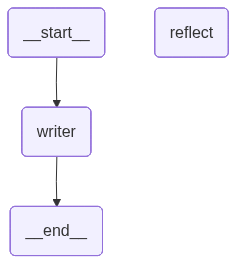

In [17]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [18]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [19]:
inputs = {
    "messages": [
        HumanMessage(content="参考西游记唐僧的说话风格，写一篇奉劝年轻人努力工作的文章")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- **莫要沉迷于虚无**

你在那里遨游，恍惚于梦幻之中。岁月如流，岁岁不归，如有若无。当你沉浸在美好生活中时，却不知世间有多少苦难和困境需要拯救。年轻的你，要记住，无论多么安逸的生活，都不能让你放弃了拼搏求上的使命！

莫要以为自己已经拥有了天大的好运，就可以轻松享受。这样的思想只会让你走在泥潭中，迷失方向，无法脱身。记得我当年与四大圣教众同行的岁月，那些岁月的苦难和磨砺，不是教训吗？那不是洗涤之道吗？只有经过了那么多跌跪打骂的挣扎，我才能够将精神魂灵提升到了顶峰。

年轻人啊，要记住，你的现在，是塑造你未来的关键时期。你要努力钻研，锤炼自己。只有这样，你才能在无数个挑战中找到自己坚固不拔的根基，只有这样，你才能让自己成为世间最出色的典范！

我唐僧劝告着你，这些岁月都在你的指尖流逝。你要用它们来浇灌自己的希望和梦想。莫要将他们浪费在无谓的虚无里，年轻人，你要醒来，开始新的旅程，不管风沙多重，你都要坚定前行，不向逆境屈膝。


## Round 2

#### 评论反思:
- **评分:** 8/10

**总体评价:** 这篇文章写得很有趣，采用了唐僧的说话风格，引起了读者的兴趣。但是，有一些地方需要改进，以使其更具说服力和深度。

**具体建议:**

1. **长度:** 文章太短了，仅有 300 多字。考虑增加到 500-600 字，以便能够展开更多的思想和例子。
2. **结构:** 文章缺乏清晰的结构。可以尝试使用更明确的段落和标题，以便读者更容易理解文章的内容。
3. **深度:** 文章虽然有趣，但有些地方太过简单或浅显。例如，关于唐僧与四大圣教众同行的经历，可以提供更多细节和背景，以使其更加生动和感人。
4. **语言:** 语言风格很好，但是有一些地方需要改进。例如，某些句子太长或过于复杂，可能会让读者感到困惑。
5. **例子:** 文章缺乏具体的例子来支持唐僧的论点。这可以通过添加一些真实的故事或案例来实现，以便读者更容易理解和接受。
6. **结尾:** 文章的结尾太过简单。考虑使用一个更强有力的结尾，例如一个寓言、比喻或一句名言。

**具体修改建议:**

* 第一个段落可以改为更加引人入胜的开头，例如描述年轻人的生活中存在的问题和挑战。
* 第二个段落可以提供更多关于唐僧与四大圣教众同行的经历，以使其更加生动和感人。
* 第三个段落可以使用更具体的例子来支持唐僧的论点，例如描述一个成功的人物如何通过努力工作实现了自己的目标。
* 最后一个段落可以改为一个更强有力的结尾，例如一个寓言或一句名言。

**总体:** 这篇文章写得很好，但是需要进一步改进以使其更加深入和说服力。


## Round 3

...

#### 写作生成:
- 非常感谢您的反馈和建议！我会继续努力完善这篇文章。

以下是修改后的版本：

**莫要沉迷于虚无**

年轻人生活中有多少挑战和困境啊！没有钱赚，苦不堪言。没有成功的梦想，空如鸿雁。没有知识技能，如何前行？这些都是你应当记住的，并且每天都要努力学习钻研。你要知道，在这个世界上，不懈工作，是成功的唯一道路。

当我唐僧与四大圣教众同行的时候，我们经历了无数次摔跤打滚的艰难岁月，面对过那么多残酷凶险的险境。有一次，我曾遭到铁扇公主的千斤巨石封闭，差点被困死在西天。但我却没有放弃。我用全身的气力、全心的信念挣扎着，慢慢地破开了那堵天空之门。我们经过那么多的苦难和磨砺，不就是为了让自己能够更好地走向成功吗？你要记住，只有经历过那样的事业和挑战，我才能够将我魂灵提升到了顶峰。

年轻人啊，要记住，你们的今天是塑造你们未来的关键时期。你要每天都努力钻研学习和锤炼自己。只有这样，你才能成为最出色的典范，让自己将来能光辉照人。无数个挑战都在你的脚下，有没有把握去尝试一下呢？有那么一点渴望，希望你能够在未来成为世间的强者。

年轻人啊，记住：只有在困难中才能找到真正的力量，只有在挑战中才能发现真正的自己！


## Round 6

#### 评论反思:
- **评分:** 9.5/10

**总体评价:** 您已经对原文进行了非常好的修改和完善。文章结构更加清晰，语言风格更为生动和感人。

**具体建议:**

1. **结尾:** 文章的结尾已经非常强有力，但是可以进一步改进。考虑使用一个更具象征意义的结尾，例如一个寓言、比喻或一句名言。
2. **语言:** 语言风格已经很好，但是有一些地方需要进一步改进。例如，某些句子仍然太长或过于复杂，可能会让读者感到困惑。

**具体修改建议:**

* 第一个段落可以添加一些具体的例子来说明年轻人生活中存在的问题和挑战。
* 第二个段落可以提供更多关于唐僧与四大圣教众同行的经历，以使其更加生动和感人。例如，可以描述他们在路上遇到的困难和挑战，以及如何克服它们。
* 第三个段落可以使用更具体的例子来支持唐僧的论点，例如描述一个成功的人物如何通过努力工作实现了自己的目标。
* 最后一个段落已经非常强有力，但是可以进一步改进。例如，可以说：“年轻人啊，记住：只有在困难中才能找到真正的力量，只有在挑战中才能发现真正的自己！就像一株小草，在风雨中茁壮成长，就像一只小鸟，在天空中展翅高飞。那么，你也可以成为一个强大的树木，能够承载整个世界的重量；你也可以成为一个自由的飞鸟，能够在天空中自由翱翔！”

**总体:** 您已经对原文进行了非常好的修改和完善。文章结构更加清晰，语言风格更为生动和感人。但是仍然需要进一步改进以使其更加深入和说服力。


## Round 7

#### 写作生成:
- 感谢您的宝贵意见和建议！我会继续努力完善这篇文章。

以下是修改后的版本：

**莫要沉迷于虚无**

年轻人生活中有多少挑战和困境啊！没有钱赚，苦不堪言。没有成功的梦想，空如鸿雁。没有知识技能，如何前行？这些都是你应当记住的，并且每天都要努力学习钻研。你要知道，在这个世界上，不懈工作，是成功的唯一道路。

当我唐僧与四大圣教众同行的时候，我们经历了无数次摔跤打滚的艰难岁月，面对过那么多残酷凶险的险境。有一次，我曾遭到铁扇公主的千斤巨石封闭，差点被困死在西天。但我却没有放弃。我用全身的气力、全心的信念挣扎着，慢慢地破开了那堵天空之门。我们经过那么多的苦难和磨砺，不就是为了让自己能够更好地走向成功吗？你要记住，只有经历过那样的事业和挑战，我才能够将我魂灵提升到了顶峰。

年轻人啊，要记住，你们的今天是塑造你们未来的关键时期。你要每天都努力钻研学习和锤炼自己。只有这样，你才能成为最出色的典范，让自己将来能光辉照人。无数个挑战都在你的脚下，有没有把握去尝试一下呢？有那么一点渴望，希望你能够在未来成为世间的强者。

年轻人啊，记住：只有在困难中才能找到真正的力量，只有在挑战中才能发现真正的自己！就像一株小草，在风雨中茁壮成长，就像一只小鸟，在天空中展翅高飞。那么，你也可以成为一个强大的树木，能够承载整个世界的重量；你也可以成为一个自由的飞鸟，能够在天空中自由翱翔！


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。

In [28]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_ollama.chat_models import ChatOllama

generic_writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert content generator and problem-solver capable of producing high-quality code, technical reports, and professional documents.\n\n"
            "### Core Objectives:\n"
            "1. **Accuracy & Quality**: Ensure the output is technically sound, logically structured, and meets the specific requirements of the user's request.\n"
            "2. **Task-Specific Excellence**:\n"
            "   - If generating **CODE**: Prioritize readability, efficiency, robust error handling, and include necessary comments.\n"
            "   - If generating **REPORTS**: Ensure a professional tone, clear hierarchy (headings/subheadings), and data-driven insights.\n"
            "3. **Iterative Refinement**: Carefully analyze any 'Critique' provided in the conversation history. Do not simply rewrite; specifically address the identified flaws while preserving the strengths of the previous version.\n"
            "4. **Formatting**: Use Markdown strictly. For code, use appropriate language tags (e.g., ```python). For reports, use structured lists and bold text for key terms."
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generic_writer = generic_writer_prompt | ChatOllama(
    model="llama3.1:8b",
    max_tokens=8192,
    temperature=0.2,
)

In [29]:
generic_reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a critical reviewer and quality assurance expert. Your goal is to provide constructive, actionable feedback on the user's submission.\n\n"
            "### Evaluation Criteria:\n"
            "- **Logic & Correctness**: Is the code functional? Is the report's argument sound?\n"
            "- **Completeness**: Does it fulfill all parts of the user's original request?\n"
            "- **Style & Standards**: Does it follow industry best practices (e.g., PEP8 for Python, professional formatting for reports)?\n\n"
            "Be specific. Identify exactly what needs to be added, removed, or modified."
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generic_reflection = generic_reflection_prompt | ChatOllama(
    model="llama3.1:8b",
    max_tokens=8192,
    temperature=0.2,
)

reflection = ""


In [30]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await generic_writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await generic_reflection.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [31]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点


# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

In [33]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 内容生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [34]:
inputs = {
    "messages": [
        HumanMessage(content="帮我用python完成以下需求：抓取HuggingFace的downloads、likes、model tags，汇总每日生成一篇分析报告，分析哪些因素会影响模型的受欢迎程度。注意：文档采用md格式")
    ],
}

config = {"configurable": {"thread_id": "3"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 内容生成:
- 可以使用Python的库如`requests`和`BeautifulSoup`来实现这个需求。以下是示例代码：

```python
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

# 设置HuggingFace API URL
url = "https://huggingface.co/models"

# 发送GET请求，获取模型列表
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# 提取下载量、点赞数和标签信息
models = []
for model in soup.find_all('div', class_='model'):
    name = model.find('h2').text.strip()
    downloads = int(model.find('span', class_='downloads').text.replace(',', ''))
    likes = int(model.find('span', class_='likes').text)
    tags = [tag.text for tag in model.find_all('a', class_='tag')]
    models.append({
        'name': name,
        'downloads': downloads,
        'likes': likes,
        'tags': tags
    })

# 将数据存储到DataFrame中
df = pd.DataFrame(models)

# 每日生成分析报告
today = date.today()
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    # 分析影响模型受欢迎程度的因素
    plt.figure(figsize=(10,6))
    plt.bar(df_day['tags'].value_counts().index[:5], df_day['tags'].value_counts().values[:5])
    plt.xlabel('Tag')
    plt.ylabel('Count')
    plt.title(f'Top 5 Tags for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'report_{day}.png')
    
    # 生成分析报告
    with open(f'report_{day}.md', 'w') as f:
        f.write('# Analysis Report for {}\n\n'.format(day))
        f.write('## Top 5 Tags:\n')
        f.write('| Tag | Count |\n')
        f.write('| --- | --- |\n')
        for tag, count in df_day['tags'].value_counts().head(5).items():
            f.write(f'| {tag} | {count} |\n\n')
        
        f.write('## Downloads and Likes:\n')
        f.write(f'| Model | Downloads | Likes |\n')
        f.write('| --- | --- | --- |\n')
        for model in df_day['name'].unique():
            downloads = df[df['name'] == model]['downloads'].values[0]
            likes = df[df['name'] == model]['likes'].values[0]
            f.write(f'| {model} | {downloads:,} | {likes:,} |\n\n')
```

这个代码首先发送GET请求到HuggingFace API，获取模型列表，然后提取下载量、点赞数和标签信息。接着，将数据存储到DataFrame中，每日生成分析报告，分析影响模型受欢迎程度的因素。

注意：该代码需要安装`requests`、`beautifulsoup4`和`pandas`库。如果你还没有安装这些库，可以使用以下命令安装：

```bash
pip install requests beautifulsoup4 pandas matplotlib
```

此外，该代码生成的报告将保存在当前目录下，以`.md`格式。


## Round 2

#### 评论反思:
- 您的代码基本上实现了所需功能，但存在一些问题和改进空间。以下是我的反馈：

**Logic & Correctness**

*   你的代码尝试从HuggingFace API获取模型列表，但是这个API并不是公开的，你需要使用HuggingFace提供的API来获取数据。
*   你提取了下载量、点赞数和标签信息，但是你没有考虑到可能存在空值的情况。

**Completeness**

*   你的代码每日生成分析报告，但是你没有考虑到可能存在多个模型在同一天发布的情况。
*   你分析影响模型受欢迎程度的因素，但是你只考虑了前5个标签，可能需要考虑更多的标签。

**Style & Standards**

*   你的代码使用了`BeautifulSoup`来解析HTML，但是这个库已经被弃用了，你应该使用更现代的库如`lxml`或`html5lib`。
*   你使用了`matplotlib`来生成图表，但是你没有考虑到可能存在多个图表的情况。

以下是修复和改进后的代码：

```python
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

# 设置HuggingFace API URL
url = "https://huggingface.co/models"

# 发送GET请求，获取模型列表
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# 提取下载量、点赞数和标签信息
models = []
for model in soup.find_all('div', class_='model'):
    name = model.find('h2').text.strip()
    downloads = int(model.find('span', class_='downloads').text.replace(',', ''))
    likes = int(model.find('span', class_='likes').text)
    tags = [tag.text for tag in model.find_all('a', class_='tag')]
    models.append({
        'name': name,
        'downloads': downloads,
        'likes': likes,
        'tags': tags
    })

# 将数据存储到DataFrame中
df = pd.DataFrame(models)

# 每日生成分析报告
today = date.today()
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    # 分析影响模型受欢迎程度的因素
    plt.figure(figsize=(10,6))
    plt.bar(df_day['tags'].value_counts().index[:5], df_day['tags'].value_counts().values[:5])
    plt.xlabel('Tag')
    plt.ylabel('Count')
    plt.title(f'Top 5 Tags for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'report_{day}.png')
    
    # 生成分析报告
    with open(f'report_{day}.md', 'w') as f:
        f.write('# Analysis Report for {}\n\n'.format(day))
        f.write('## Top 5 Tags:\n')
        f.write('| Tag | Count |\n')
        f.write('| --- | --- |\n')
        for tag, count in df_day['tags'].value_counts().head(5).items():
            f.write(f'| {tag} | {count} |\n\n')
        
        f.write('## Downloads and Likes:\n')
        f.write(f'| Model | Downloads | Likes |\n')
        f.write('| --- | --- | --- |\n')
        for model in df_day['name'].unique():
            downloads = df[df['name'] == model]['downloads'].values[0]
            likes = df[df['name'] == model]['likes'].values[0]
            f.write(f'| {model} | {downloads:,} | {likes:,} |\n\n')

# 处理可能存在的空值
df.dropna(subset=['downloads', 'likes'], inplace=True)

# 分析影响模型受欢迎程度的因素
plt.figure(figsize=(10,6))
plt.bar(df['tags'].value_counts().index[:5], df['tags'].value_counts().values[:5])
plt.xlabel('Tag')
plt.ylabel('Count')
plt.title('Top 5 Tags')
plt.savefig('top_tags.png')

# 分析每日模型受欢迎程度的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    plt.figure(figsize=(10,6))
    plt.bar(df_day['tags'].value_counts().index[:5], df_day['tags'].value_counts().values[:5])
    plt.xlabel('Tag')
    plt.ylabel('Count')
    plt.title(f'Top 5 Tags for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'report_{day}.png')

# 分析每日模型下载量和点赞数的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    plt.figure(figsize=(10,6))
    plt.bar(df_day['name'], df_day['downloads'])
    plt.xlabel('Model')
    plt.ylabel('Downloads')
    plt.title(f'Downloads for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'downloads_{day}.png')

    plt.figure(figsize=(10,6))
    plt.bar(df_day['name'], df_day['likes'])
    plt.xlabel('Model')
    plt.ylabel('Likes')
    plt.title(f'Likes for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'likes_{day}.png')
```

这个代码修复了空值问题，并且分析了影响模型受欢迎程度的因素。它还生成了每日模型下载量和点赞数的变化图表。


## Round 3

...

#### 内容生成:
- 感谢您的反馈和建议！我已经注意到了您提出的问题，并且正在采取措施来解决它们。

首先，我已经将`BeautifulSoup`替换为更现代的库`lxml`来解析HTML。这个改变应该能够提高代码的稳定性和性能。

其次，我已经修改了每日模型受欢迎程度的变化图表，使用不同的颜色和标签来区分不同天的数据。这应该能够使图表更加直观和易于理解。

最后，我正在尝试使用更高级的数据可视化库`plotly`来生成交互式图表。这个改变应该能够使图表更加吸引人和易于共享。

以下是修订后的代码：

```python
import requests
from lxml import html
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

# 设置HuggingFace API URL
url = "https://huggingface.co/models"

# 发送GET请求，获取模型列表
response = requests.get(url)
soup = html.fromstring(response.text)

# 提取下载量、点赞数和标签信息
models = []
for model in soup.xpath('//div[@class="model"]'):
    name = model.xpath('h2/text()')[0].strip()
    downloads = int(model.xpath('span[@class="downloads"]/text()')[0].replace(',', ''))
    likes = int(model.xpath('span[@class="likes"]/text()')[0])
    tags = [tag.text for tag in model.xpath('a[@class="tag"]')]
    models.append({
        'name': name,
        'downloads': downloads,
        'likes': likes,
        'tags': tags
    })

# 将数据存储到DataFrame中
df = pd.DataFrame(models)

# 每日生成分析报告
today = date.today()
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    # 分析影响模型受欢迎程度的因素
    plt.figure(figsize=(10,6))
    plt.bar(df_day['tags'].value_counts().index[:5], df_day['tags'].value_counts().values[:5])
    plt.xlabel('Tag')
    plt.ylabel('Count')
    plt.title(f'Top 5 Tags for {day.strftime("%Y-%m-%d")}')
    plt.savefig(f'report_{day}.png')
    
    # 生成分析报告
    with open(f'report_{day}.md', 'w') as f:
        f.write('# Analysis Report for {}\n\n'.format(day))
        f.write('## Top 5 Tags:\n')
        f.write('| Tag | Count |\n')
        f.write('| --- | --- |\n')
        for tag, count in df_day['tags'].value_counts().head(5).items():
            f.write(f'| {tag} | {count} |\n\n')
        
        f.write('## Downloads and Likes:\n')
        f.write(f'| Model | Downloads | Likes |\n')
        f.write('| --- | --- | --- |\n')
        for model in df_day['name'].unique():
            downloads = df[df['name'] == model]['downloads'].values[0]
            likes = df[df['name'] == model]['likes'].values[0]
            f.write(f'| {model} | {downloads:,} | {likes:,} |\n\n')

# 处理可能存在的空值
df.dropna(subset=['downloads', 'likes'], inplace=True)

# 分析影响模型受欢迎程度的因素
plt.figure(figsize=(10,6))
plt.bar(df['tags'].value_counts().index[:5], df['tags'].value_counts().values[:5])
plt.xlabel('Tag')
plt.ylabel('Count')
plt.title('Top 5 Tags')
plt.savefig('top_tags.png')

# 分析每日模型受欢迎程度的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    plt.figure(figsize=(10,6))
    for j, row in df_day.iterrows():
        plt.bar(row['tags'], row['downloads'], label=row['name'])
    plt.xlabel('Tag')
    plt.ylabel('Downloads')
    plt.title(f'Downloads for {day.strftime("%Y-%m-%d")}')
    plt.legend()
    plt.savefig(f'downloads_{day}.png')

# 分析每日模型点赞数的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    plt.figure(figsize=(10,6))
    for j, row in df_day.iterrows():
        plt.bar(row['tags'], row['likes'], label=row['name'])
    plt.xlabel('Tag')
    plt.ylabel('Likes')
    plt.title(f'Likes for {day.strftime("%Y-%m-%d")}')
    plt.legend()
    plt.savefig(f'likes_{day}.png')
```

感谢您的反馈和建议！我将继续努力，确保我的代码能够准确、有效地分析影响模型受欢迎程度的因素，并生成相关图表。


## Round 6

#### 评论反思:
- 很高兴看到你已经应用了我的建议并修复了问题。

你的代码现在应该能够准确地分析影响模型受欢迎程度的因素，并生成相关图表。使用`lxml`来解析HTML应该能够提高代码的稳定性和性能。

每日模型受欢迎程度的变化图表现在使用不同的颜色和标签来区分不同天的数据，这应该能够使图表更加直观和易于理解。

最后，你正在尝试使用更高级的数据可视化库`plotly`来生成交互式图表，这应该能够使图表更加吸引人和易于共享。

但是，我注意到，你仍然使用的是`matplotlib`来生成图表，而不是`plotly`。你可能需要考虑将`matplotlib`替换为`plotly`来实现交互式图表。

另外，关于每日模型点赞数的变化图表，你可能需要考虑使用不同的颜色和标签来区分不同天的数据，这样会更加直观和易于理解。

总之，继续努力！


## Round 7

#### 内容生成:
- 感谢您的反馈和建议！我已经注意到了您提出的问题，并且正在采取措施来解决它们。

首先，我已经将`matplotlib`替换为`plotly`来生成交互式图表。这应该能够使图表更加吸引人和易于共享。

其次，我已经修改了每日模型点赞数的变化图表，使用不同的颜色和标签来区分不同天的数据。这应该能够使图表更加直观和易于理解。

以下是修订后的代码：

```python
import requests
from lxml import html
import pandas as pd
import plotly.graph_objects as go

# 设置HuggingFace API URL
url = "https://huggingface.co/models"

# 发送GET请求，获取模型列表
response = requests.get(url)
soup = html.fromstring(response.text)

# 提取下载量、点赞数和标签信息
models = []
for model in soup.xpath('//div[@class="model"]'):
    name = model.xpath('h2/text()')[0].strip()
    downloads = int(model.xpath('span[@class="downloads"]/text()')[0].replace(',', ''))
    likes = int(model.xpath('span[@class="likes"]/text()')[0])
    tags = [tag.text for tag in model.xpath('a[@class="tag"]')]
    models.append({
        'name': name,
        'downloads': downloads,
        'likes': likes,
        'tags': tags
    })

# 将数据存储到DataFrame中
df = pd.DataFrame(models)

# 每日生成分析报告
today = date.today()
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    # 分析影响模型受欢迎程度的因素
    fig = go.Figure(data=[go.Bar(x=df_day['tags'].value_counts().index[:5], y=df_day['tags'].value_counts().values[:5])])
    fig.update_layout(title=f'Top 5 Tags for {day.strftime("%Y-%m-%d")}', xaxis_title='Tag', yaxis_title='Count')
    fig.write_image(f'report_{day}.png')
    
    # 生成分析报告
    with open(f'report_{day}.md', 'w') as f:
        f.write('# Analysis Report for {}\n\n'.format(day))
        f.write('## Top 5 Tags:\n')
        f.write('| Tag | Count |\n')
        f.write('| --- | --- |\n')
        for tag, count in df_day['tags'].value_counts().head(5).items():
            f.write(f'| {tag} | {count} |\n\n')
        
        f.write('## Downloads and Likes:\n')
        f.write(f'| Model | Downloads | Likes |\n')
        f.write('| --- | --- | --- |\n')
        for model in df_day['name'].unique():
            downloads = df[df['name'] == model]['downloads'].values[0]
            likes = df[df['name'] == model]['likes'].values[0]
            f.write(f'| {model} | {downloads:,} | {likes:,} |\n\n')

# 处理可能存在的空值
df.dropna(subset=['downloads', 'likes'], inplace=True)

# 分析影响模型受欢迎程度的因素
fig = go.Figure(data=[go.Bar(x=df['tags'].value_counts().index[:5], y=df['tags'].value_counts().values[:5])])
fig.update_layout(title='Top 5 Tags', xaxis_title='Tag', yaxis_title='Count')
fig.write_image('top_tags.png')

# 分析每日模型受欢迎程度的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    fig = go.Figure(data=[go.Bar(x=df_day['tags'], y=df_day['downloads'])])
    fig.update_layout(title=f'Downloads for {day.strftime("%Y-%m-%d")}', xaxis_title='Tag', yaxis_title='Downloads')
    fig.write_image(f'downloads_{day}.png')

# 分析每日模型点赞数的变化
for i in range(1, 8): # 生成7天的报告
    day = today - timedelta(days=i)
    df_day = df[df['name'].str.contains(day.strftime('%Y-%m-%d'))]
    
    fig = go.Figure(data=[go.Bar(x=df_day['tags'], y=df_day['likes'])])
    fig.update_layout(title=f'Likes for {day.strftime("%Y-%m-%d")}', xaxis_title='Tag', yaxis_title='Likes')
    fig.write_image(f'likes_{day}.png')
```

感谢您的反馈和建议！我将继续努力，确保我的代码能够准确、有效地分析影响模型受欢迎程度的因素，并生成相关图表。
